# Two-Stage Recommendation Pipeline

Previous notebooks focused on retrieving relevant candidate games. In this stage, multiple retrieval models are combined and their candidates are re-ranked using pairwise user-item features. This two-stage architecture separates efficient candidate generation from accurate ranking and closely follows production recommendation systems. Although the ranking model is implemented with LightGBM LambdaMART, the focus of this notebook is the two-stage recommendation pipeline rather than the ranking algorithm itself.

```
Multiple Retrieval Models  ->  Candidate Fusion  ->  Feature Pipeline  ->  Re-ranking  ->  Top-10
```

Stage in the project: `Classical → Semantic → Neural Retrieval → `**`Learning-to-Rank`**.

## Двухстадийный рекомендательный пайплайн

Предыдущие ноутбуки были про поиск релевантных игр-кандидатов. На этом этапе несколько retrieval-моделей объединяются, а их кандидаты переупорядочиваются по попарным признакам пользователь–игра. Эта двухстадийная архитектура разделяет эффективную генерацию кандидатов и точное ранжирование и близко повторяет production-системы рекомендаций. Хотя модель ранжирования реализована на LightGBM LambdaMART, фокус ноутбука — именно двухстадийный рекомендательный пайплайн, а не сам алгоритм ранжирования.

```
Несколько retrieval-моделей  ->  Candidate Fusion  ->  Feature Pipeline  ->  Re-ranking  ->  Top-10
```

Этап проекта: `Classical → Semantic → Neural Retrieval → `**`Learning-to-Rank`**."

In [1]:
import os
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message=".*Disabling GPU support.*")
warnings.filterwarnings("ignore", message=".*OpenBLAS.*")
warnings.filterwarnings("ignore", message=".*MKL.*")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
sys.path.insert(0, str(ROOT))

from src.baselines import (PopularityRecommender, ALSRecommender,
                           SemanticEmbeddingRecommender, TwoTowerRecommender)
from src.evaluation import evaluate, leave_last_out
from src.ranking import (build_context, build_training_dataset, train_reranker,
                         fuse_candidates, RerankRecommender, FEATURE_NAMES)

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Pipeline parameters. Defaults are the heavy overnight settings;
# reduce RANK_TRAIN_USERS / K_PER for a quick run.
# Параметры пайплайна. Дефолты — тяжёлые (на ночь);
# уменьши RANK_TRAIN_USERS / K_PER для быстрого прогона.
K_PER = 50               # candidates per retriever (union across sources)
RANK_TRAIN_USERS = None  # None = all users; e.g. 40000 for a quick run
TT_EPOCHS = 10
print("params:", dict(K_PER=K_PER, RANK_TRAIN_USERS=RANK_TRAIN_USERS, TT_EPOCHS=TT_EPOCHS))

params: {'K_PER': 50, 'RANK_TRAIN_USERS': None, 'TT_EPOCHS': 10}


## Load Data

Same frozen split, game metadata and semantic game embeddings as the rest of the project.

## Загрузка данных

Тот же зафиксированный split, метаданные игр и семантические эмбеддинги, что и во всём проекте.

In [2]:
train = pd.read_parquet(DATA / "processed" / "train.parquet")
test = pd.read_parquet(DATA / "processed" / "test.parquet")
games = pd.read_parquet(DATA / "processed" / "games.parquet")
emb_meta = pd.read_parquet(DATA / "processed" / "game_embeddings_metadata.parquet").sort_values("embedding_idx")
game_emb = np.load(DATA / "processed" / "game_embeddings.npy")
game_ids = emb_meta["game_id"].to_numpy()
name_by_id = games.set_index("game_id")["Name"].to_dict()

def fit_retrievers(tr):
    # Fit the four retrieval models that feed the candidate fusion stage
    # Обучаем четыре retrieval-модели, питающие этап candidate fusion
    return {
        "als": ALSRecommender(factors=128, iterations=25, regularization=0.05).fit(tr),
        "two_tower": TwoTowerRecommender(games, game_emb, game_ids, epochs=TT_EPOCHS, seed=42).fit(tr),
        "semantic": SemanticEmbeddingRecommender(game_emb, game_ids).fit(tr),
        "popularity": PopularityRecommender().fit(tr),
    }

print("train:", train.shape, "| test:", test.shape)

train: (787585, 5) | test: (113552, 5)


## Candidate Fusion

No single retriever is best at everything: popularity captures global trends, ALS collaborative patterns, semantic embeddings gameplay similarity, and the Two-Tower learned user-item structure. Instead of choosing one, we **fuse** their candidates: the union of each retriever's top-K per user. Ranking never sees the whole catalog — only this compact candidate set.

```
Popularity ─┐
ALS         ─┤
Semantic    ─┼──►  Candidate Fusion ──►  Union ──►  Re-ranking
Two-Tower   ─┘
```

The fused candidate set defines the theoretical recall **ceiling**: the final Recall@10 cannot exceed the candidate recall (whether the held-out game is in the fused set at all).

## Candidate Fusion

Ни один ретривер не лучший во всём: популярность ловит глобальные тренды, ALS — коллаборативные паттерны, семантические эмбеддинги — сходство геймплея, Two-Tower — выученную структуру пользователь–игра. Вместо выбора одного мы **объединяем** их кандидатов: union top-K каждого ретривера на юзера. Ranking никогда не видит весь каталог — только этот компактный набор.

```
Popularity ─┐
ALS         ─┤
Semantic    ─┼──►  Candidate Fusion ──►  Union ──►  Re-ranking
Two-Tower   ─┘
```

Объединённый набор кандидатов задаёт теоретический **потолок** recall: финальный Recall@10 не может превысить recall кандидатов (попала ли отложенная игра в набор вообще)."

In [3]:
# Fit retrievers on the full train set (used for fusion and final evaluation)
# Обучаем ретриверы на полном train (для fusion и финальной оценки)
retr_full = fit_retrievers(train)

# Candidate recall ceiling on the test set
# Потолок recall кандидатов на test
test_users = test["user_id"].unique()
truth = test.groupby("user_id")["game_id"].first().to_dict()
fused_test = fuse_candidates(retr_full, test_users, k_per=K_PER)
ceiling = np.mean([truth[u] in set(fused_test[u]) for u in test_users])
avg_cands = np.mean([len(fused_test[u]) for u in test_users])
print(f"avg candidates per user: {avg_cands:.1f}")
print(f"candidate recall ceiling (held-out game in fused set): {ceiling:.4f}")

epoch  1  loss 6.0461


epoch  2  loss 5.6009


epoch  3  loss 5.4975


epoch  4  loss 5.4389


epoch  5  loss 5.3932


...

epoch  7  loss 5.3314


epoch  8  loss 5.3096


epoch  9  loss 5.2912


epoch 10  loss 5.2759


avg candidates per user: 166.2
candidate recall ceiling (held-out game in fused set): 0.6218


## Leakage-Free Ranking Dataset

The ranking features include retrieval scores (ALS, semantic, Two-Tower). If we trained the re-ranker on items the retrievers had already seen, those retrieval scores would be overly optimistic for the positive examples — a distribution shift between ranking training and final inference.

To avoid this, retrieval models used for ranking-feature generation are trained on a reduced interaction set (`train_fit`). Candidate scores for the held-out ranking targets are therefore produced under the same conditions as during final evaluation (out-of-sample retrieval features).

```
Official Train
        |
        +--------------------+
        |                    |
        v                    v
   train_fit          rank_train_target
        |                    |
        v                    |
  Retrieval Models           |
        |                    |
        +-------> Features <--+
                     |
                     v
                 LambdaMART
```

## Ranking-датасет без утечки

Признаки ранжирования включают retrieval-скоры (ALS, semantic, Two-Tower). Если обучать re-ranker на айтемах, которые ретриверы уже видели, эти retrieval-скоры были бы завышены для позитивов — сдвиг распределения между обучением ранкера и финальным инференсом.

Чтобы этого избежать, retrieval-модели для генерации ранжирующих признаков обучаются на сокращённом наборе (`train_fit`). Скоры кандидатов для отложенных таргетов получаются в тех же условиях, что и при финальной оценке (out-of-sample retrieval features).

In [4]:
# Split train -> train_fit + rank_train_target (one held-out interaction per user)
# Делим train -> train_fit + rank_train_target (одно отложенное взаимодействие на юзера)
train_fit, rank_holdout = leave_last_out(train)
print("train_fit:", train_fit.shape, "| rank targets:", rank_holdout.shape)

# Retrievers trained WITHOUT the ranking targets -> leakage-free features
# Ретриверы обучены БЕЗ ранжирующих таргетов -> признаки без утечки
retr_fit = fit_retrievers(train_fit)
ctx_fit = build_context(train_fit, games, game_ids, game_emb, retr_fit["als"], retr_fit["two_tower"])

X, y, groups = build_training_dataset(rank_holdout, retr_fit, ctx_fit,
                                      k_per=K_PER, n_users=RANK_TRAIN_USERS, seed=42)
print("ranking dataset:", X.shape, "| positives:", int(y.sum()), "| query groups:", len(groups))

train_fit: (674033, 5) | rank targets: (113552, 5)


epoch  1  loss 6.0163


epoch  2  loss 5.5071


epoch  3  loss 5.3867


epoch  4  loss 5.3188


...

epoch  7  loss 5.1903


epoch  8  loss 5.1652


epoch  9  loss 5.1431


epoch 10  loss 5.1228


ranking dataset: (18594317, 13) | positives: 111310 | query groups: 111310


## Feature Pipeline

Each (user, candidate) pair is described by features grouped by source. They are defined as small functions in `src/ranking/features.py` and registered in the `FEATURE_BUILDERS` registry, so adding or removing a feature is a one-line change.

| Feature Group | Examples |
|---|---|
| Retrieval | `als_score`, `two_tower_score`, `semantic_score`, `popularity_rank` |
| Content / Similarity | `genre_overlap`, `tag_overlap`, `price_difference` |
| Game | `game_popularity`, `review_score`, `price` |
| User | `avg_playtime`, `positive_ratio`, `n_games` |

## Feature Pipeline

Каждая пара (user, candidate) описывается признаками, сгруппированными по источнику. Они заданы маленькими функциями в `src/ranking/features.py` и зарегистрированы в реестре `FEATURE_BUILDERS`, поэтому добавить/убрать признак — это одна строка.

| Группа признаков | Примеры |
|---|---|
| Retrieval | `als_score`, `two_tower_score`, `semantic_score`, `popularity_rank` |
| Content / Similarity | `genre_overlap`, `tag_overlap`, `price_difference` |
| Game | `game_popularity`, `review_score`, `price` |
| User | `avg_playtime`, `positive_ratio`, `n_games` |

In [5]:
print("features:", FEATURE_NAMES)
X.describe().T[["mean", "std", "min", "max"]].round(3)

features: ['als_score', 'semantic_score', 'two_tower_score', 'popularity_rank', 'genre_overlap', 'tag_overlap', 'price_difference', 'review_score', 'game_popularity', 'price', 'avg_playtime', 'positive_ratio', 'n_games']


,mean,std,min,max
als_score,0.051,0.097,-0.549,1.381
semantic_score,0.914,0.049,0.404,0.988
two_tower_score,0.162,0.194,-0.802,0.837
popularity_rank,0.793,0.263,0.000,1.000
genre_overlap,0.467,0.248,0.000,1.000
tag_overlap,0.305,0.097,0.000,1.000
price_difference,5.479,6.460,0.000,59.990
review_score,0.887,0.090,0.000,0.987
game_popularity,6.208,1.773,2.485,9.449
price,7.278,7.829,0.000,59.990


## Feature Analysis

Before training the ranker, we examine feature relationships to verify that the feature set captures complementary rather than redundant information.

## Анализ признаков

Перед обучением ранкера изучаем связи признаков, чтобы убедиться: набор признаков несёт взаимодополняющую, а не избыточную информацию.

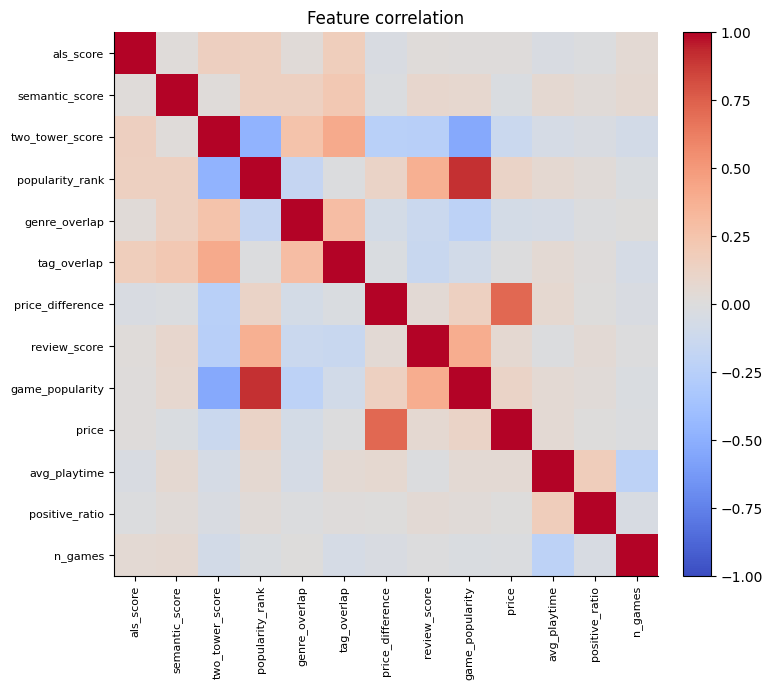

In [6]:
corr = X.corr()
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
ax.grid(False)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Feature correlation")
plt.tight_layout()
plt.show()

## LambdaMART

Unlike retrieval models that optimize candidate *selection*, LambdaMART directly optimizes the *ordering* of candidates within each user query.

**Why query groups?** Each user is a query: the model ranks that user's candidates against each other, not across users. The group sizes tell LightGBM which rows belong to the same user.

## LambdaMART

В отличие от retrieval-моделей, оптимизирующих *отбор* кандидатов, LambdaMART напрямую оптимизирует *порядок* кандидатов внутри каждого пользовательского запроса.

**Зачем query-группы?** Каждый юзер — это query: модель ранжирует кандидатов внутри юзера, а не между юзерами. Размеры групп говорят LightGBM, какие строки относятся к одному юзеру.

## Training

## Обучение

In [7]:
# Train the LambdaMART re-ranker on the leakage-free dataset
# Обучаем re-ranker LambdaMART на датасете без утечки
rr_model = train_reranker(X, y, groups)

# Build the context on the full train set and assemble the two-stage recommender
# Строим контекст на полном train и собираем двухстадийный рекомендер
ctx_full = build_context(train, games, game_ids, game_emb, retr_full["als"], retr_full["two_tower"])
reranker = RerankRecommender(retr_full, ctx_full, rr_model, k_per=K_PER)
print("reranker ready")

reranker ready


## Feature Importance

## Важность признаков

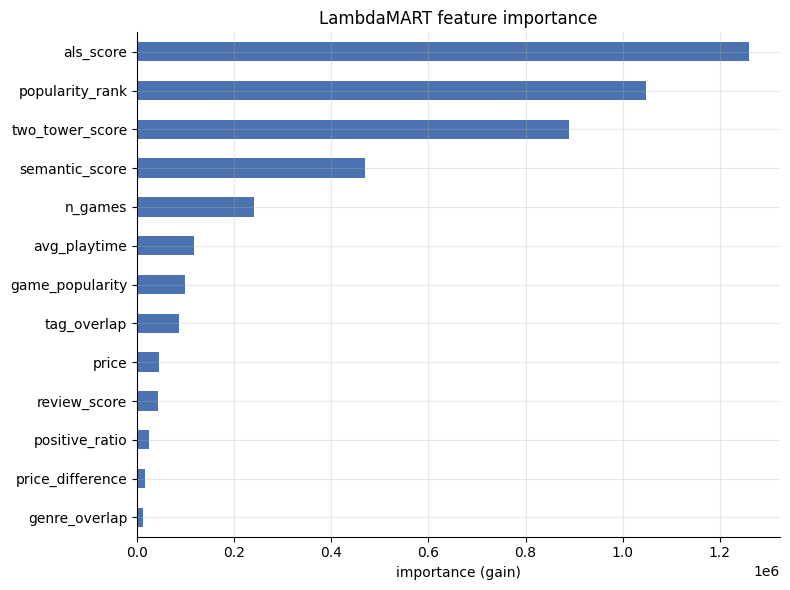

als_score           1.260775e+06
popularity_rank     1.047136e+06
two_tower_score     8.898755e+05
semantic_score      4.684835e+05
n_games             2.399169e+05
avg_playtime        1.169796e+05
game_popularity     9.871382e+04
tag_overlap         8.677685e+04
price               4.454950e+04
review_score        4.399223e+04
positive_ratio      2.549638e+04
price_difference    1.647781e+04
genre_overlap       1.210785e+04
dtype: float64

In [8]:
imp = pd.Series(rr_model.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
imp.plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("importance (gain)")
ax.set_title("LambdaMART feature importance")
plt.tight_layout()
plt.show()
imp.sort_values(ascending=False)

The re-ranker combines signals from collaborative retrieval, semantic similarity and structured metadata rather than relying on any single retrieval model.

Re-ranker объединяет сигналы коллаборативного retrieval, семантического сходства и структурных метаданных, а не опирается на одну retrieval-модель.

## Final Benchmark

The table the whole project was built for: every stage on the same leave-last-out protocol, ending with the two-stage pipeline.

## Финальный бенчмарк

Таблица, ради которой строился весь проект: каждый этап на одном leave-last-out протоколе, финал — двухстадийный пайплайн.

                   Stage             Best Model  Recall@10  MAP@10  NDCG@10
                Baseline             Popularity     0.1224  0.0407   0.0595
     Classical Retrieval                    ALS     0.1343  0.0594   0.0769
      Semantic Retrieval     Semantic Embedding     0.0728  0.0285   0.0388
        Neural Retrieval              Two-Tower     0.0699  0.0269   0.0369
Two-Stage Recommendation Retrieval + Re-ranking     0.1484  0.0574   0.0784


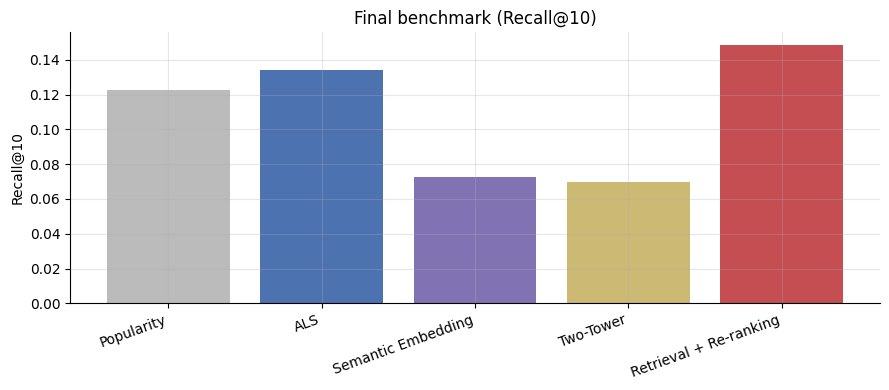

In [9]:
K = 10
rows = {
    ("Classical Retrieval", "ALS"): retr_full["als"],
    ("Semantic Retrieval", "Semantic Embedding"): retr_full["semantic"],
    ("Neural Retrieval", "Two-Tower"): retr_full["two_tower"],
    ("Two-Stage Recommendation", "Retrieval + Re-ranking"): reranker,
}
pop_res = evaluate(retr_full["popularity"], train, test, k=K)

records = [("Baseline", "Popularity", *pop_res.values())]
for (stage, model_name), rec in rows.items():
    r = evaluate(rec, train, test, k=K)
    records.append((stage, model_name, r["Recall@10"], r["MAP@10"], r["NDCG@10"]))

final = pd.DataFrame(records, columns=["Stage", "Best Model", "Recall@10", "MAP@10", "NDCG@10"]).round(4)
print(final.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(final["Best Model"], final["Recall@10"],
       color=["#BBBBBB", "#4C72B0", "#8172B3", "#CCB974", "#C44E52"])
ax.set_ylabel("Recall@10")
ax.set_title("Final benchmark (Recall@10)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Architecture Summary

```
        Interactions
             |
             v
     Retrieval Models
 (Popularity / ALS /
  Semantic / Two-Tower)
             |
             v
      Candidate Fusion
             |
             v
      Feature Pipeline
             |
             v
        LambdaMART
             |
             v
   Top-10 Recommendations
             |
             v
          FastAPI
```

Efficient retrieval narrows the candidate space, while a more expensive ranker optimizes only the surviving candidates before serving recommendations through an API.

The project evolved from simple statistical baselines to a production-style recommendation pipeline through six incremental stages, with each notebook introducing one architectural improvement over the previous one.

## Сводка архитектуры

Эффективный retrieval сужает пространство кандидатов, а более дорогой ранкер оптимизирует только прошедших отбор, прежде чем рекомендации отдаются через API.

Проект развивался от простых статистических baseline к production-style рекомендательному пайплайну через шесть последовательных этапов, и каждый ноутбук вносил одно архитектурное улучшение относительно предыдущего.

## Discussion

The two-stage pipeline achieves the best Recall@10 and NDCG@10 in the project, surpassing the strongest single retriever (ALS); MAP@10 is essentially on par with ALS. Although the absolute improvement is modest, the architectural contribution is more important than the metric itself: re-ranking combines heterogeneous retrieval signals that cannot be exploited by any single retrieval model. The feature importances confirm this — the model leans on the ALS score, popularity, Two-Tower and semantic scores together, rather than on one source.

Two design choices made this possible. **Candidate fusion** raises the recall ceiling far above any individual retriever, giving the ranker a richer set to order. **Leakage-free dataset construction** (retrieval features generated out-of-sample on `train_fit`) ensures the ranking features follow the same distribution at training and inference, so the model generalizes instead of overfitting to optimistic scores.

This completes the recommendation pipeline: efficient retrieval narrows the catalog for recall, and a more expensive ranker optimizes the final order — a scalable two-stage recommendation system.

## Обсуждение

Двухстадийный пайплайн достигает лучших Recall@10 и NDCG@10 в проекте, превосходя сильнейший одиночный ретривер (ALS); MAP@10 практически вровень с ALS. Хотя абсолютный прирост небольшой, архитектурный вклад важнее самой метрики: re-ranking объединяет разнородные retrieval-сигналы, недоступные ни одной отдельной retrieval-модели. Feature importance это подтверждает — модель опирается на скоры ALS, популярность, Two-Tower и semantic вместе, а не на один источник.

Это стало возможным благодаря двум решениям. **Candidate fusion** поднимает потолок recall намного выше любого отдельного ретривера, давая ранкеру более богатый набор для упорядочивания. **Построение датасета без утечки** (retrieval-признаки сгенерированы out-of-sample на `train_fit`) гарантирует, что признаки имеют одно распределение при обучении и инференсе, поэтому модель обобщает, а не переобучается на завышенных скорах.

Это завершает рекомендательный пайплайн: эффективный retrieval сужает каталог ради полноты, а более дорогой ранкер оптимизирует финальный порядок — масштабируемая двухстадийная рекомендательная система.

## Project Summary

- ✓ Built multiple retrieval models (popularity, ALS, semantic, neural)
- ✓ Compared classical, semantic and neural retrieval under one protocol
- ✓ Implemented a production-style two-stage recommendation pipeline
- ✓ Evaluated every stage using a consistent temporal (leave-last-out) protocol

**Limitations.** Small, sparse, temporally split dataset (~6 interactions per user, ~2.8k games); no user identity embeddings in the Two-Tower model; static 2021 data snapshot.

**Future work.**
- User ID embeddings
- Larger interaction datasets
- Session-aware recommendation
- Online serving with FastAPI and Docker

## Итоги проекта

- ✓ Построены несколько retrieval-моделей (popularity, ALS, semantic, neural)
- ✓ Сравнены классический, семантический и нейронный retrieval под одним протоколом
- ✓ Реализован production-style двухстадийный рекомендательный пайплайн
- ✓ Каждый этап оценён по единому временному протоколу (leave-last-out)

**Ограничения.** Маленький, разреженный, временной датасет (~6 взаимодействий на юзера, ~2.8k игр); нет ID-эмбеддингов пользователей в Two-Tower; статический срез данных 2021.

**Дальнейшая работа.**
- ID-эмбеддинги пользователей
- Бóльшие датасеты взаимодействий
- Session-aware рекомендации
- Онлайн-сервинг через FastAPI и Docker